# Experiment Utilities with ``braintools``

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chaobrain/brainx/blob/main/docs/tutorials/braintools_expriment_utilities.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/chaobrain/brainx/blob/main/docs/tutorials/braintools_expriment_utilities.ipynb)

## What is `braintools`?

`braintools` is the experiment-utility package in the BrainX ecosystem. It fills the practical gaps around neural dynamics models: task construction, input generation, parameter initialization, connectivity generation, file I/O, metric calculation, optimization, numerical integration, surrogate gradients, visualization, and spike encoding.

It is useful to think of `braintools` as the utility layer between a model and a full experiment. Packages such as `brainstate` and `braincell` focus on model states, neural dynamics, and simulation objects. `braintools` focuses on how those objects are organized into runnable, analyzable, and reproducible experiment workflows.

For deeper explanations, extended examples, and complete API references, see the full [braintools documentation](https://brainx.chaobrain.com/braintools/).

This tutorial follows a typical experiment workflow. It starts with setup, then introduces cognitive tasks, connectivity, file processing, initialization, input currents, metrics, optimization, numerical integration, surrogate gradients, visualization, and spike encoding. The final section combines several utilities into a compact end-to-end example.

## Module overview

| Module or utility | Main purpose | Example in this tutorial |
| --- | --- | --- |
| [`braintools.cogtask`](https://brainx.chaobrain.com/braintools/cogtask/index.html) | Build cognitive tasks, trial features, task phases, and sampled trial data | Use `Feature` and `PerceptualDecisionMaking` to generate inputs, targets, and trial metadata |
| [`braintools.conn`](https://brainx.chaobrain.com/braintools/conn/index.html) | Generate neuron-to-neuron connectivity, sparse indices, weight matrices, and delays | Use `AllToAll` and `FixedProb` to build dense and random connectivity |
| [`braintools.file`](https://brainx.chaobrain.com/braintools/file/index.html) | Save and load parameters, checkpoints, and other pytree experiment artifacts | Use `msgpack_save` and `msgpack_load` to write and read a parameter dictionary |
| [`braintools.init`](https://brainx.chaobrain.com/braintools/init/index.html) | Initialize model parameters, state variables, synaptic weights, and readout weights | Use `Normal`, `XavierNormal`, and `Constant` to create arrays or connection weights |
| [`braintools.input`](https://brainx.chaobrain.com/braintools/input/index.html) | Generate common stimulus protocols and input currents, such as step, sinusoidal, noise, and Poisson spike inputs | Use `step`, `sinusoidal`, and `poisson` to create time-series inputs |
| [`braintools.metric`](https://brainx.chaobrain.com/braintools/metric/index.html) | Compute neural activity metrics and machine-learning losses | Use `firing_rate`, cross entropy, and squared error to evaluate outputs |
| [`braintools.optim`](https://brainx.chaobrain.com/braintools/optim/index.html) | Update trainable `brainstate` parameters | Use `SGD` to minimize a simple quadratic loss |
| [`braintools.quad`](https://brainx.chaobrain.com/braintools/quad/index.html) | Provide numerical integration steps for ODEs, SDEs, DDEs, and IMEX systems | Use `ode_rk4_step` to integrate first-order decay dynamics |
| [`braintools.surrogate`](https://brainx.chaobrain.com/braintools/surrogate/index.html) | Provide differentiable surrogate gradients for non-differentiable spike functions | Use a `sigmoid` spike function to inspect forward spikes and gradients |
| [`braintools.visualize`](https://brainx.chaobrain.com/braintools/visualize/index.html) | Plot raster plots, population activity, connectivity matrices, learning curves, and related figures | Use `raster_plot` and `population_activity` to visualize spike data |
| [`braintools.RateEncoder`](https://brainx.chaobrain.com/braintools/misc/spike_encoding.html) | Convert continuous values or input intensities into spike trains | Encode analog inputs as Bernoulli spike trains according to firing rate |

Each section below corresponds to one utility category in the table. You can first scan the overview, then use the code examples to see where each tool fits in an experiment workflow.

## 1. Setup

The examples use short arrays and small time windows so the outputs are easy to inspect. Time-dependent utilities use `brainunit` units and the global `brainstate` time step. Random examples set explicit seeds when the API exposes one, so saved outputs are reproducible across documentation builds.


In [49]:
import tempfile
from pathlib import Path

import braintools
import brainstate
import brainunit as u
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from braintools import cogtask, conn, file, init, input, metric, optim, quad, surrogate, visualize

brainstate.environ.set(dt=1.0 * u.ms)
brainstate.random.seed(0)

print(f"simulation dt: {brainstate.environ.get_dt()}")


simulation dt: 1. ms


## 2. Cognitive Tasks

Cognitive-task utilities describe experiments in terms of features, phases, and trial sampling. A feature specifies part of the input or target vector. A phase specifies an interval such as fixation, stimulus, delay, or response. A task combines these pieces into trial data that can drive a model.

Full documentation: [Cognitive Tasks](https://brainx.chaobrain.com/braintools/cogtask/index.html)

In [50]:
# Feature sets map named task variables into slices of a trial input vector.
features = cogtask.Feature(1, "fixation") + cogtask.Feature(2, "motion") + cogtask.Feature(2, "choice")

print(features)
print(f"total input dimensions: {features.num}")
print(f"fixation slice: {features['fixation'].i}")
print(f"motion slice:   {features['motion'].i}")
print(f"choice slice:   {features['choice'].i}")

FeatureSet(names=['fixation', 'motion', 'choice'], nums=[1, 2, 2])
total input dimensions: 5
fixation slice: slice(0, 1, None)
motion slice:   slice(1, 3, None)
choice slice:   slice(3, 5, None)


In [51]:
# A ready-made perceptual decision-making task returns trial inputs, targets, and metadata.
task = cogtask.PerceptualDecisionMaking(
    t_fixation=20 * u.ms,
    t_stimulus=40 * u.ms,
    t_response=20 * u.ms,
    pop_per_choice=2,
    seed=0,
)

trial_inputs, trial_targets, trial_info = task.sample_trial(0)

print(task)
print(f"input shape:  {trial_inputs.shape}")
print(f"target shape: {trial_targets.shape}")
print(f"phases:       {trial_info['phase_history']}")
print(f"trial state:  {trial_info['trial_state']}")

Task(name=PerceptualDecisionMaking, inputs=5, outputs=3, output_mode=categorical)
input shape:  (80, 5)
target shape: (80,)
phases:       [('fixation', 0, 20), ('stimulus', 20, 60), ('response', 60, 80), ('Sequence', 60, 80)]
trial state:  {'trial_index': 0, 'ground_truth': Array(0, dtype=int32), 'coherence': Array(25.6, dtype=float32), 'stimulus_direction': Array(0., dtype=float32), 'output_mode': 'categorical'}


## 3. Synaptic Connectivity

Connectivity helpers create connection lists and optional weights or delays. The resulting `ConnectionResult` exposes sparse connection indices and conversion helpers such as `weight2dense()` and `weight2csr()`. In these arrays, `pre_indices[k] -> post_indices[k]` identifies one directed connection, while `weights[k]` stores the corresponding synaptic weight when a weight initializer is provided.

Full documentation: [Synaptic Connectivity](https://brainx.chaobrain.com/braintools/conn/index.html)


In [52]:
all_to_all = conn.AllToAll(
    include_self_connections=False,
    weight=init.Constant(0.5),
)
result = all_to_all(pre_size=4, post_size=4)

print(f"shape: {result.shape}")
print(f"number of connections: {result.n_connections}")
print(f"pre indices:  {result.pre_indices}")
print(f"post indices: {result.post_indices}")
print("dense weights:")
print(result.weight2dense())

shape: (4, 4)
number of connections: 12
pre indices:  [0 0 0 1 1 1 2 2 2 3 3 3]
post indices: [1 2 3 0 2 3 0 1 3 0 1 2]
dense weights:
[[0.  0.5 0.5 0.5]
 [0.5 0.  0.5 0.5]
 [0.5 0.5 0.  0.5]
 [0.5 0.5 0.5 0. ]]


In [53]:
# Fixed-probability connectivity is useful for random network sketches.
# The seed is passed through the base Connectivity class for reproducible examples.
random_conn = conn.FixedProb(
    prob=0.35,
    allow_self_connections=False,
    weight=init.Constant(0.2),
    seed=1,
)
random_result = random_conn(pre_size=5, post_size=4)

print(f"random connection count: {random_result.n_connections}")
print("dense random weights:")
print(random_result.weight2dense())


random connection count: 8
dense random weights:
[[0.  0.  0.  0.2]
 [0.2 0.  0.2 0.2]
 [0.2 0.2 0.  0. ]
 [0.  0.  0.  0. ]
 [0.2 0.  0.2 0. ]]


## 4. File Processing

File utilities save and load pytrees such as parameter dictionaries. This is useful for checkpoints, initialized parameters, and experiment artifacts.

Full documentation: [File Processing](https://brainx.chaobrain.com/braintools/file/index.html)

In [54]:
params = {
    "weights": jnp.arange(6, dtype=jnp.float32).reshape(2, 3),
    "bias": jnp.array([0.1, -0.2], dtype=jnp.float32),
}

checkpoint_path = Path(tempfile.gettempdir()) / "braintools_tutorial_checkpoint.msgpack"
file.msgpack_save(str(checkpoint_path), params, overwrite=True, verbose=False)
loaded_params = file.msgpack_load(str(checkpoint_path), verbose=False)
checkpoint_path.unlink(missing_ok=True)

print("loaded keys:", sorted(loaded_params.keys()))
print("loaded weights:")
print(loaded_params["weights"])
print("loaded bias:", loaded_params["bias"])

loaded keys: ['bias', 'weights']
loaded weights:
[[0. 1. 2.]
 [3. 4. 5.]]
loaded bias: [ 0.1 -0.2]


## 5. Initialization

Initialization utilities create arrays for model parameters, synaptic weights, and readout layers. Distribution-based initializers are convenient for neuroscience-style parameters, while Xavier and Kaiming initializers are useful for trainable neural-network layers.

Full documentation: [Initialization](https://brainx.chaobrain.com/braintools/init/index.html)

In [55]:
rng = np.random.default_rng(0)

normal_weights = init.Normal(mean=0.0, std=0.1)((4, 3), rng=rng)
xavier_weights = init.XavierNormal()((4, 3), rng=rng)

print("Normal initializer")
print(f"  shape: {normal_weights.shape}")
print(f"  mean/std: {normal_weights.mean():.4f} / {normal_weights.std():.4f}")

print("Xavier normal initializer")
print(f"  shape: {xavier_weights.shape}")
print(f"  mean/std: {xavier_weights.mean():.4f} / {xavier_weights.std():.4f}")

Normal initializer
  shape: (4, 3)
  mean/std: 0.0022 / 0.0704
Xavier normal initializer
  shape: (4, 3)
  mean/std: -0.1338 / 0.5093


## 6. Input Current

Input utilities generate common stimulation protocols: steps, ramps, oscillations, pulses, noise, and Poisson spike input. Unit-aware durations make the protocol align with the simulation time step. In practice, pass time arguments with units such as `u.ms` or `u.Hz`; this keeps protocol generation consistent with the global `brainstate` time step.

Full documentation: [Input Current](https://brainx.chaobrain.com/braintools/input/index.html)


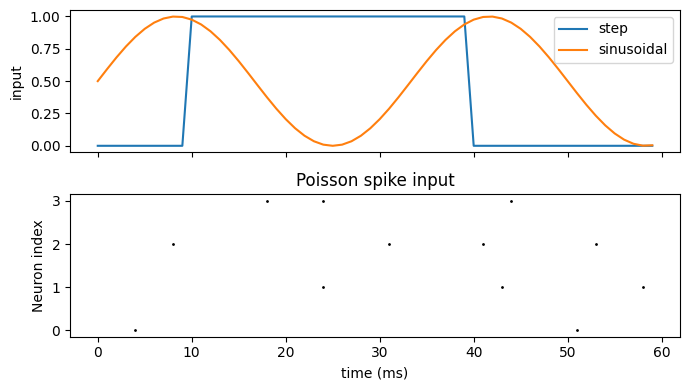

In [56]:
step_current = input.step(
    amplitudes=[0.0, 1.0, 0.0],
    step_times=[0 * u.ms, 10 * u.ms, 40 * u.ms],
    duration=60 * u.ms,
)

sine_current = input.sinusoidal(
    amplitude=0.5,
    frequency=30 * u.Hz,
    duration=60 * u.ms,
    bias=True,
)

poisson_spikes = input.poisson(
    rate=40 * u.Hz,
    duration=60 * u.ms,
    n=4,
    seed=0,
)

time_ms = np.arange(step_current.shape[0])

fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
axes[0].plot(time_ms, step_current, label="step")
axes[0].plot(time_ms, sine_current, label="sinusoidal")
axes[0].set_ylabel("input")
axes[0].legend(loc="upper right")

visualize.raster_plot(time_ms, poisson_spikes, ax=axes[1], markersize=4, show=False)
axes[1].set_title("Poisson spike input")
axes[1].set_xlabel("time (ms)")
plt.tight_layout()
plt.show()

## 7. Metric Function

Metrics cover neural activity analysis and machine-learning objectives. The same module can compute firing rates, spike-train distances, classification losses, and regression errors.

Full documentation: [Metric Function](https://brainx.chaobrain.com/braintools/metric/index.html)

In [57]:
spike_matrix = jnp.array(
    [
        [0, 1, 0, 0],
        [1, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 0, 0],
        [1, 0, 0, 0],
    ],
    dtype=jnp.float32,
)

population_rate = metric.firing_rate(spike_matrix, width=2.0, dt=1.0)
logits = jnp.array([[2.0, 0.0, -1.0], [0.1, 0.5, 1.2]])
labels = jnp.array([0, 2])
classification_loss = metric.softmax_cross_entropy_with_integer_labels(logits, labels)
regression_error = metric.squared_error(jnp.array([0.9, 1.8]), jnp.array([1.0, 2.0]), reduction="mean")

print("smoothed population firing rate:", population_rate)
print("classification loss per sample:", classification_loss)
print("mean squared error:", regression_error)

smoothed population firing rate: [0.375 0.5   0.375 0.25  0.125]
classification loss per sample: [0.16984604 0.6040188 ]
mean squared error: 0.025000012


## 8. Optimization

Optimization utilities provide familiar optimizers for trainable `brainstate` parameters. The example below minimizes a one-parameter quadratic loss with SGD.

Full documentation: [Optimization](https://brainx.chaobrain.com/braintools/optim/index.html)

In [58]:
w = brainstate.ParamState(jnp.array(0.0), name="w")
optimizer = optim.SGD(lr=0.2)
optimizer.register_trainable_weights({"w": w})

history = []
for step in range(6):
    loss, grad = jax.value_and_grad(lambda value: (value - 3.0) ** 2)(w.value)
    optimizer.update({"w": grad})
    history.append((step, float(loss), float(w.value)))

for step, loss, value in history:
    print(f"step {step}: loss={loss:.4f}, w={value:.4f}")

step 0: loss=9.0000, w=1.2000
step 1: loss=3.2400, w=1.9200
step 2: loss=1.1664, w=2.3520
step 3: loss=0.4199, w=2.6112
step 4: loss=0.1512, w=2.7667
step 5: loss=0.0544, w=2.8600


## 9. Numerical Integration

Numerical integration utilities implement single-step ODE, SDE, DDE, and IMEX methods. They are useful when you want a specific integration rule outside a larger simulator.

Full documentation: [Numerical Integration](https://brainx.chaobrain.com/braintools/quad/index.html)

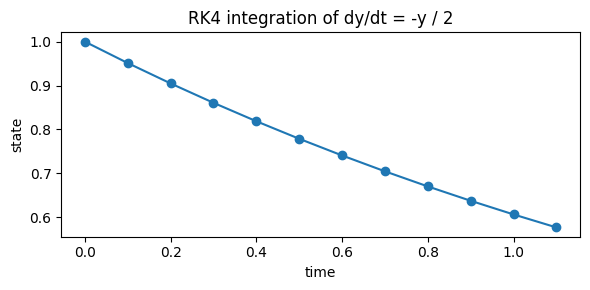

In [59]:
brainstate.environ.set(dt=0.1)

def decay(y, t):
    return -y / 2.0

y = jnp.array(1.0)
t = 0.0
trajectory = []
for _ in range(12):
    trajectory.append(float(y))
    y = quad.ode_rk4_step(decay, y, t)
    t += brainstate.environ.get_dt()

brainstate.environ.set(dt=1.0 * u.ms)

plt.figure(figsize=(6, 3))
plt.plot(np.arange(len(trajectory)) * 0.1, trajectory, marker="o")
plt.xlabel("time")
plt.ylabel("state")
plt.title("RK4 integration of dy/dt = -y / 2")
plt.tight_layout()
plt.show()

## 10. Surrogate Gradients

Binary spike functions are not differentiable in the usual sense. Surrogate-gradient functions keep the forward pass spike-like while supplying a smooth gradient to JAX autodiff.

Full documentation: [Surrogate Gradients](https://brainx.chaobrain.com/braintools/surrogate/index.html)

x:                  [-1.5   -1.125 -0.75  -0.375  0.     0.375  0.75   1.125  1.5  ]
forward spikes:     [0. 0. 0. 0. 1. 1. 1. 1. 1.]
surrogate gradient: [0.00986604 0.04346492 0.18070664 0.59658587 1.         0.59658587
 0.18070662 0.04346485 0.00986586]


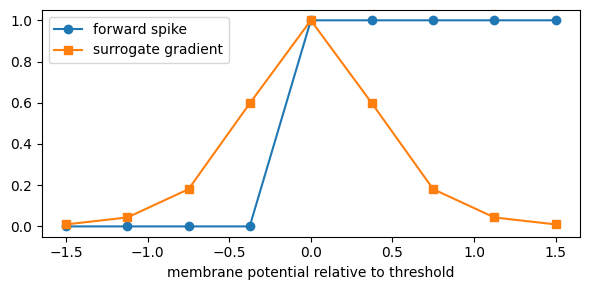

In [60]:
x = jnp.linspace(-1.5, 1.5, 9)
spikes = surrogate.sigmoid(x, alpha=4.0)
grads = jax.grad(lambda z: jnp.sum(surrogate.sigmoid(z, alpha=4.0)))(x)

print("x:                 ", x)
print("forward spikes:    ", spikes)
print("surrogate gradient:", grads)

plt.figure(figsize=(6, 3))
plt.plot(x, spikes, "o-", label="forward spike")
plt.plot(x, grads, "s-", label="surrogate gradient")
plt.xlabel("membrane potential relative to threshold")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Visualization

Visualization utilities provide ready-made plots for spike rasters, population activity, connectivity matrices, learning curves, trajectories, and related neural data views.

Full documentation: [Visualization](https://brainx.chaobrain.com/braintools/visualize/index.html)

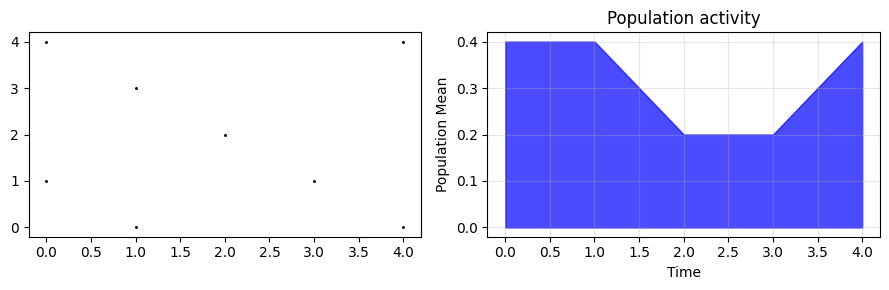

In [61]:
example_spikes = np.array(
    [
        [0, 1, 0, 0, 1],
        [1, 0, 0, 1, 0],
        [0, 0, 1, 0, 0],
        [0, 1, 0, 0, 0],
        [1, 0, 0, 0, 1],
    ],
    dtype=float,
)
example_time = np.arange(example_spikes.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
visualize.raster_plot(example_time, example_spikes, ax=axes[0], markersize=5, show=False)
visualize.population_activity(example_spikes, time=example_time, method="mean", ax=axes[1], title="Population activity")
plt.tight_layout()
plt.show()

## 12. Spike Encoding Methods

Spike encoders convert continuous values into spike trains. `RateEncoder` maps each input value to a firing rate in Hz, then samples Bernoulli spikes at each simulation step. With the default `dt = 1 ms`, a 100 Hz rate corresponds to a spike probability of about `0.1` per step.

The example below uses enough time steps to make the sampled spike probability close to the expected probability, while the raster plot only shows the first part of the generated train.

Full documentation: [Spike Encoding Methods](https://brainx.chaobrain.com/braintools/misc/spike_encoding.html)

analog values: [0.1 0.5 0.9]
encoded spike shape: (1000, 3)
expected spike probability per step: [0.01 0.05 0.09]
observed spike probability over 1000 steps: [0.013      0.042      0.09500001]


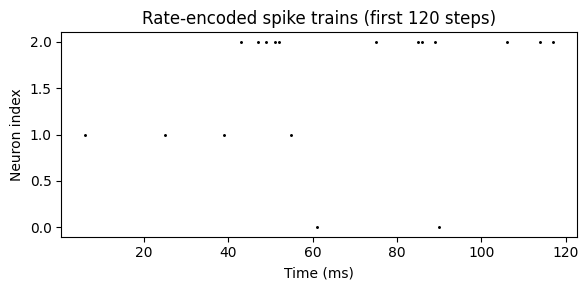

In [62]:
brainstate.random.seed(1)

analog_values = jnp.array([0.1, 0.5, 0.9])
n_time = 1000
rate_gain_hz = 100.0

rate_encoder = braintools.RateEncoder(gain=rate_gain_hz, method="linear")
encoded_spikes = rate_encoder(analog_values, n_time=n_time)

# RateEncoder uses rate_hz * dt_ms / 1000 as the Bernoulli probability.
dt_ms = float(u.get_mantissa(brainstate.environ.get_dt()))
expected_probability = analog_values * rate_gain_hz * dt_ms / 1000.0
observed_probability = jnp.mean(encoded_spikes, axis=0)

print(f"analog values: {analog_values}")
print(f"encoded spike shape: {encoded_spikes.shape}")
print(f"expected spike probability per step: {expected_probability}")
print(f"observed spike probability over {n_time} steps: {observed_probability}")

plot_steps = 120
plt.figure(figsize=(6, 3))
visualize.raster_plot(
    np.arange(plot_steps),
    np.asarray(encoded_spikes[:plot_steps]),
    markersize=5,
    show=False,
)
plt.title(f"Rate-encoded spike trains (first {plot_steps} steps)")
plt.tight_layout()
plt.show()

## 13. Mini Workflow

A typical experiment uses several `braintools` modules together. This mini workflow builds a time-varying input protocol, expands it into a small presynaptic population, encodes the drive values as spike trains, sends the spikes through an all-to-all projection, and summarizes the resulting readout currents.

The goal is to show how the utilities fit together in one compact pipeline: input generation, spike encoding, connectivity construction, simple synaptic filtering, metric calculation, and visualization. The same pattern can be extended to larger networks or replaced with more detailed neuron and synapse models when needed.

In [63]:
brainstate.random.seed(3)

dt = 1.0 * u.ms
brainstate.environ.set(dt=dt)
dt_ms = float(u.get_mantissa(dt))
n_steps = 200

# 1. Build a scalar input protocol with baseline, stimulus, and recovery phases.
stimulus = input.step(
    amplitudes=[0.1, 0.9, 0.25],
    step_times=[0 * u.ms, 50 * u.ms, 150 * u.ms],
    duration=n_steps * u.ms,
)
time_ms = np.arange(n_steps) * dt_ms
stimulus_array = jnp.asarray(stimulus[:n_steps])

# 2. Expand the scalar protocol into a small presynaptic population.
# The first 12 units follow excitatory-style weights; the last 4 use inhibitory-style weights.
n_stim_exc = 8
n_context_exc = 4
n_inh = 4
n_pre = n_stim_exc + n_context_exc + n_inh

stim_tuning = jnp.linspace(0.45, 1.0, n_stim_exc)
context_tuning = jnp.linspace(0.45, 0.8, n_context_exc)
inh_tuning = jnp.linspace(0.5, 0.9, n_inh)

stim_exc_drive = stimulus_array[:, None] * stim_tuning[None, :]
context_exc_drive = (0.35 + 0.10 * (1.0 - stimulus_array))[:, None] * context_tuning[None, :]
inh_drive = (0.20 + 0.25 * stimulus_array)[:, None] * inh_tuning[None, :]
presynaptic_drive = jnp.clip(
    jnp.concatenate([stim_exc_drive, context_exc_drive, inh_drive], axis=1),
    0.0,
    1.0,
)

# 3. Encode drives into presynaptic spikes with a rate-based encoder.
encoder = braintools.RateEncoder(gain=35.0, min_rate=2.0, method="linear")
presynaptic_spikes = encoder(presynaptic_drive, n_time=1)[0]

# 4. Convert spikes into a simple exponential synaptic trace before readout.
tau_syn_ms = 10.0
alpha = float(np.exp(-dt_ms / tau_syn_ms))
syn_state = jnp.zeros(n_pre, dtype=jnp.float32)
synaptic_trace = []
for spikes_t in presynaptic_spikes:
    syn_state = alpha * syn_state + spikes_t
    synaptic_trace.append(syn_state)
synaptic_trace = jnp.stack(synaptic_trace)

# 5. Create an all-to-all projection structure and apply two readout weight profiles.
connection_mask = jnp.asarray(
    conn.AllToAll(weight=init.Constant(1.0))(pre_size=n_pre, post_size=2).weight2dense()
)

stim_w0 = jnp.linspace(0.035, 0.075, n_stim_exc)
stim_w1 = jnp.linspace(0.015, 0.035, n_stim_exc)
context_w0 = jnp.linspace(0.015, 0.030, n_context_exc)
context_w1 = jnp.linspace(0.035, 0.060, n_context_exc)
inh_w0 = -jnp.linspace(0.025, 0.045, n_inh)
inh_w1 = -jnp.linspace(0.030, 0.055, n_inh)

readout_pattern = jnp.concatenate(
    [
        jnp.stack([stim_w0, stim_w1], axis=1),
        jnp.stack([context_w0, context_w1], axis=1),
        jnp.stack([inh_w0, inh_w1], axis=1),
    ],
    axis=0,
)
weights = connection_mask * readout_pattern
readout_current = synaptic_trace @ weights

# 6. Evaluate spike rates and readout currents.
presynaptic_rate = metric.firing_rate(presynaptic_spikes, width=20 * u.ms, dt=dt)
spike_counts = np.asarray(jnp.sum(presynaptic_spikes, axis=0))
observed_rates_hz = spike_counts * 1000.0 / (n_steps * dt_ms)
presynaptic_rate_np = np.asarray(presynaptic_rate)
readout_current_np = np.asarray(readout_current)

print(f"presynaptic drive:       {presynaptic_drive.shape}")
print(f"presynaptic spikes:      {presynaptic_spikes.shape}")
print(f"synaptic trace:          {synaptic_trace.shape}")
print(f"weights:                 {weights.shape}")
print(f"readout current:         {readout_current.shape}")
print(
    "observed pre rates:     "
    f"min={observed_rates_hz.min():.1f} Hz, "
    f"mean={observed_rates_hz.mean():.1f} Hz, "
    f"max={observed_rates_hz.max():.1f} Hz"
)
print(
    "population rate:        "
    f"min={presynaptic_rate_np.min():.1f} Hz, "
    f"mean={presynaptic_rate_np.mean():.1f} Hz, "
    f"max={presynaptic_rate_np.max():.1f} Hz"
)
print(
    "readout current ranges: "
    f"unit 0 [{readout_current_np[:, 0].min():.3f}, {readout_current_np[:, 0].max():.3f}], "
    f"unit 1 [{readout_current_np[:, 1].min():.3f}, {readout_current_np[:, 1].max():.3f}]"
)
print(f"excitatory-style weights nonnegative: {bool(jnp.all(weights[: n_stim_exc + n_context_exc] >= 0.0))}")
print(f"inhibitory-style weights nonpositive: {bool(jnp.all(weights[n_stim_exc + n_context_exc :] <= 0.0))}")

presynaptic drive:       (200, 16)
presynaptic spikes:      (200, 16)
synaptic trace:          (200, 16)
weights:                 (16, 2)
readout current:         (200, 2)
observed pre rates:     min=5.0 Hz, mean=11.2 Hz, max=30.0 Hz
population rate:        min=0.0 Hz, mean=11.7 Hz, max=28.1 Hz
readout current ranges: unit 0 [-0.044, 0.255], unit 1 [-0.051, 0.118]
excitatory-style weights nonnegative: True
inhibitory-style weights nonpositive: True


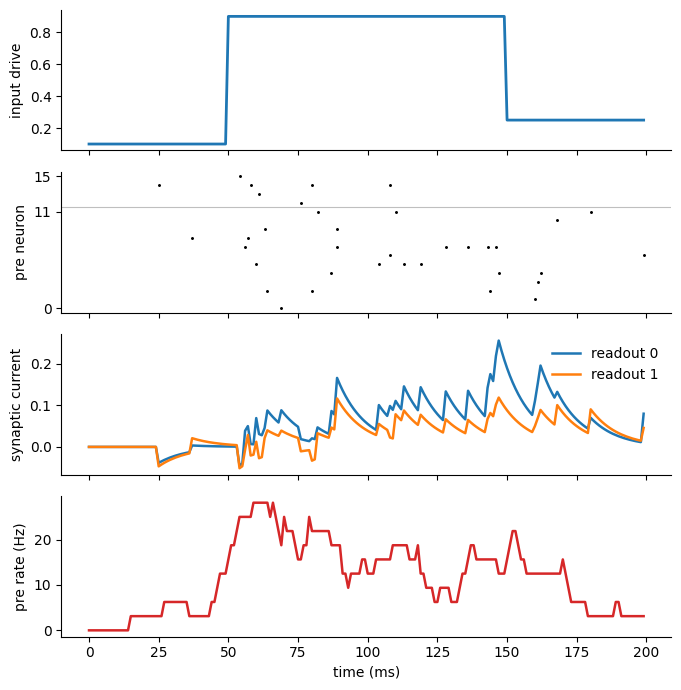

In [64]:
fig, axes = plt.subplots(4, 1, figsize=(7, 7), sharex=True)
axes[0].plot(time_ms, np.asarray(stimulus_array), color="tab:blue", linewidth=2)
axes[0].set_ylabel("input drive")

visualize.raster_plot(
    time_ms,
    np.asarray(presynaptic_spikes),
    ax=axes[1],
    markersize=5,
    xlabel=None,
    ylabel=None,
    show=False,
)
axes[1].axhline(n_stim_exc + n_context_exc - 0.5, color="0.75", linewidth=0.8)
axes[1].set_ylabel("pre neuron")
axes[1].set_yticks([0, n_stim_exc + n_context_exc - 1, n_pre - 1])
axes[1].set_ylim(-0.5, n_pre - 0.5)

axes[2].plot(time_ms, readout_current_np[:, 0], label="readout 0", linewidth=1.8)
axes[2].plot(time_ms, readout_current_np[:, 1], label="readout 1", linewidth=1.8)
axes[2].set_ylabel("synaptic current")
axes[2].legend(frameon=False, loc="upper right")

axes[3].plot(time_ms, presynaptic_rate_np, color="tab:red", linewidth=1.8)
axes[3].set_ylabel("pre rate (Hz)")
axes[3].set_xlabel("time (ms)")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 14. Summary

This notebook introduced `braintools` as a practical utility layer for BrainX experiments. The examples showed how to generate cognitive-task trials, build synaptic connectivity, save and load pytrees, initialize parameters, create input currents, compute metrics, run optimization steps, apply numerical integration, use surrogate gradients, visualize neural activity, and encode continuous values as spike trains.

The main idea is that `braintools` helps connect the pieces around a simulation: experiment design, data generation, model support utilities, analysis, and visualization. This page is an entry point for the package. For deeper explanations, extended examples, and complete API references, follow the section-level links above or open the full [braintools documentation](https://brainx.chaobrain.com/braintools/).
